> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 2. Mathematical Foundations

*Scope:* The linear algebra, calculus, probability and statistics the algorithm chapters actually use — every idea computed in NumPy rather than only stated.

Mathematics earns its place in this material only where it changes what you *do*. Every section below
answers a question that comes up later: why a linear model is a dot product (2.1), why the normal equation
sometimes explodes (2.4), what PCA is actually computing (2.5), where gradient descent's update rule comes
from (2.6), and why Naive Bayes works in log space (2.7).

Nothing here is proved. Everything here is computed — the point is to make each idea concrete enough to
recognize when it reappears wearing an algorithm's clothing. The notation table in §25.3 of the index is
the reference for symbols.

In [1]:
import numpy as np

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=3, suppress=True)   # readable output for the whole chapter

### 2.1 Vectors and Vector Operations

A **vector** is an ordered list of numbers. In machine learning it is almost always one of two things:

| The vector | What it holds | Length |
|---|---|---|
| $\mathbf{x}^{(i)}$ — one row of $X$ | One instance's feature values | $p$, the number of features |
| $\mathbf{w}$ — the weight vector | One learned coefficient per feature | $p$ |

Both live in the same $p$-dimensional space, which is what makes the geometry meaningful: a model's weights
and a data point can be compared directly.

Addition and scalar multiplication work element-wise, and NumPy writes them exactly as the maths does.

In [2]:
x = np.array([2.0, 3.0, 5.0])    # one instance, 3 features
w = np.array([0.5, -1.0, 2.0])   # one weight per feature

print("x + w      ", x + w)        # [ 2.5  2.  7. ]  - element-wise
print("3 * x      ", 3 * x)        # [ 6.  9. 15. ]   - scales every component
print("x.shape    ", x.shape)      # (3,) - one dimension, length 3

x + w       [2.5 2.  7. ]
3 * x       [ 6.  9. 15.]
x.shape     (3,)


#### 2.1.1 The dot product

The **dot product** of two vectors multiplies them element-wise and sums the result:

$$\mathbf{w} \cdot \mathbf{x} = \sum_{j=1}^{p} w_j x_j$$

This single operation is the arithmetic core of most of Chapters 11–13. A linear model's prediction for one
instance *is* a dot product plus an intercept:

$$\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$$

Written as a loop it is obvious; written as `@` it is the same thing, faster and closer to the notation.

In [3]:
b = 1.0

by_hand = sum(w[j] * x[j] for j in range(len(x))) + b
by_numpy = w @ x + b        # "@" is the dot/matrix-multiply operator

print("by hand :", by_hand)    # 9.0  -> (0.5*2) + (-1*3) + (2*5) + 1
print("by numpy:", by_numpy)   # 9.0
print("np.dot  :", np.dot(w, x) + b)   # identical - "@" and np.dot agree for 1-D vectors

by hand : 9.0
by numpy: 9.0
np.dot  : 9.0


#### 2.1.2 What the dot product means geometrically

The dot product also equals

$$\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \, \|\mathbf{b}\| \cos\theta$$

where $\theta$ is the angle between the two vectors. That gives it a directional reading, which is what
makes it useful far beyond arithmetic:

| Dot product | Angle | Interpretation |
|---|---|---|
| Positive | Less than 90° | The vectors point broadly the same way |
| Zero | Exactly 90° | **Orthogonal** — no shared direction at all |
| Negative | More than 90° | They point broadly opposite ways |

Orthogonality is the property PCA is built on (2.5): principal components are chosen to be mutually
orthogonal, so each one carries information the others do not.

In [4]:
a = np.array([1.0, 0.0])
b_vec = np.array([0.0, 1.0])
c = np.array([1.0, 1.0])

print("a . b =", a @ b_vec)   # 0.0  -> orthogonal, at right angles
print("a . c =", a @ c)        # 1.0  -> positive, sharing a direction
print("a . -c =", a @ -c)      # -1.0 -> negative, opposed

cos_theta = (a @ c) / (np.linalg.norm(a) * np.linalg.norm(c))
print("angle a-c:", np.degrees(np.arccos(cos_theta)).round(1), "degrees")   # 45.0

a . b = 0.0
a . c = 1.0
a . -c = -1.0
angle a-c: 45.0 degrees


**Common mistake — confusing a 1-D vector with a 2-D column.** `(3,)` and `(3, 1)` look interchangeable and
are not. scikit-learn requires `X` to be 2-D and `y` to be 1-D (1.4), and mixing the two shapes is the most
common source of a confusing broadcast result — NumPy will not raise an error, it will silently produce a
matrix where a vector was intended.

In [5]:
flat = np.array([1.0, 2.0, 3.0])      # shape (3,)   - a 1-D vector
column = flat.reshape(-1, 1)           # shape (3, 1) - a 2-D column

print(flat.shape, column.shape)        # (3,) (3, 1)
print("flat - flat:  ", (flat - flat).shape)        # (3,)   - as expected
print("column - flat:", (column - flat).shape)      # (3, 3) - NOT an error, and almost never what you wanted

(3,) (3, 1)
flat - flat:   (3,)
column - flat: (3, 3)


### 2.2 Matrices and Matrix Operations

A **matrix** is a rectangular grid of numbers. The feature matrix $X$ is the one that matters: $n$ rows
(instances) by $p$ columns (features), exactly the shape scikit-learn expects.

| Operation | Notation | NumPy | Shape rule |
|---|---|---|---|
| Transpose | $X^\top$ | `X.T` | $(n, p) \to (p, n)$ |
| Matrix–vector product | $X\mathbf{w}$ | `X @ w` | $(n, p) \times (p,) \to (n,)$ |
| Matrix–matrix product | $AB$ | `A @ B` | $(n, k) \times (k, m) \to (n, m)$ |
| Element-wise product | $A \odot B$ | `A * B` | Same shape in, same shape out |
| Identity | $I$ | `np.eye(n)` | $AI = A$ |
| Inverse | $A^{-1}$ | `np.linalg.inv(A)` | Square, non-singular only (2.4) |

The second row is the one worth internalizing: **`X @ w` computes every prediction at once.** The loop over
instances that a beginner writes is already inside the matrix product.

In [6]:
X = np.array([[2.0, 3.0, 5.0],     # instance 0
              [1.0, 0.0, 4.0],     # instance 1
              [0.0, 2.0, 1.0]])    # instance 2

loop_preds = np.array([w @ X[i] + b for i in range(X.shape[0])])
matrix_preds = X @ w + b   # all three predictions in one operation

print("loop  :", loop_preds)     # [9.  9.5 1. ]
print("matrix:", matrix_preds)   # identical
print("equal :", np.allclose(loop_preds, matrix_preds))   # True

loop  : [9.  9.5 1. ]
matrix: [9.  9.5 1. ]
equal : True


The shapes are the contract: `X` is `(3, 3)`, `w` is `(3,)`, and the product is `(3,)` — one prediction per
row. The inner dimensions must match, and NumPy will refuse if they do not.

In [7]:
print("X.shape", X.shape, "@ w.shape", w.shape, "->", (X @ w).shape)   # (3, 3) @ (3,) -> (3,)

try:
    X @ np.array([1.0, 2.0])   # length 2 against 3 columns
except ValueError as e:
    print("ValueError:", str(e)[:70])

X.shape (3, 3) @ w.shape (3,) -> (3,)
ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with g


**Common mistake — using `*` where `@` was meant.** In NumPy `*` is element-wise multiplication, not matrix
multiplication. For two matrices of the same shape both operations are legal and return different things,
so there is no error to catch — just a wrong answer. (In MATLAB and in the mathematics, `*` *is* matrix
multiplication, which is where the habit comes from.)

In [8]:
A = np.array([[1.0, 2.0],
              [3.0, 4.0]])

print("A * A (element-wise):\n", A * A)     # squares each entry
print("A @ A (matrix product):\n", A @ A)   # a genuinely different matrix

A * A (element-wise):
 [[ 1.  4.]
 [ 9. 16.]]
A @ A (matrix product):
 [[ 7. 10.]
 [15. 22.]]


### 2.3 Norms, Distance and Similarity

A **norm** measures the size of a vector. Different norms measure "size" differently, and the choice is not
cosmetic — it is what separates ridge from lasso (Chapter 12) and one k-NN metric from another (14.2).

| Norm | Formula | Also called | Where it appears |
|---|---|---|---|
| $L_1$ | $\sum_j \lvert v_j \rvert$ | Manhattan, taxicab | Lasso's penalty (12.3), Manhattan distance |
| $L_2$ | $\sqrt{\sum_j v_j^2}$ | Euclidean | Ridge's penalty (12.2), ordinary distance |
| $L_\infty$ | $\max_j \lvert v_j \rvert$ | Chebyshev, max | Rare; worst-case bounds |

`np.linalg.norm` computes all of them through its `ord` argument.

In [9]:
v = np.array([3.0, -4.0])

print("L1  :", np.linalg.norm(v, ord=1))         # 7.0  -> 3 + 4
print("L2  :", np.linalg.norm(v, ord=2))         # 5.0  -> sqrt(9 + 16), the classic 3-4-5 triangle
print("Linf:", np.linalg.norm(v, ord=np.inf))   # 4.0  -> the largest single component

L1  : 7.0
L2  : 5.0
Linf: 4.0


#### 2.3.1 Distance is the norm of a difference

Every distance metric in Chapter 14 is a norm applied to the difference between two points:

$$d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\|$$

Change the norm and you change the metric — and, in k-NN, the neighbours it finds.

In [10]:
p1 = np.array([1.0, 2.0])
p2 = np.array([4.0, 6.0])
diff = p1 - p2

print("Euclidean (L2):", np.linalg.norm(diff))            # 5.0
print("Manhattan (L1):", np.linalg.norm(diff, ord=1))   # 7.0 - longer: no diagonal shortcut

Euclidean (L2): 5.0
Manhattan (L1): 7.0


#### 2.3.2 Cosine similarity

Distance cares about magnitude; **cosine similarity** cares only about direction. Rearranging the geometric
dot-product identity from 2.1.2:

$$\text{cos-sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|} \in [-1, 1]$$

This matters wherever magnitude is an artefact rather than a signal. Two documents represented as word
counts (6.6) can be about exactly the same thing while one is ten times longer; Euclidean distance calls
them far apart, cosine similarity calls them identical.

In [11]:
def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))


short_doc = np.array([1.0, 2.0, 1.0])    # word counts
long_doc = np.array([10.0, 20.0, 10.0])  # same proportions, ten times as long
other_doc = np.array([5.0, 0.0, 0.0])     # genuinely different content

print("euclidean short-long:", np.linalg.norm(short_doc - long_doc).round(2))   # 22.05 - "far apart"
print("cosine    short-long:", cosine_similarity(short_doc, long_doc).round(3))   # 1.000 - identical direction
print("cosine    short-other:", cosine_similarity(short_doc, other_doc).round(3))  # 0.408 - genuinely different

euclidean short-long: 22.05
cosine    short-long: 1.0
cosine    short-other: 0.408


### 2.4 Linear Systems, Rank and Invertibility

Fitting a linear model by the normal equation (11.3) means solving a linear system. Understanding when that
system has no unique solution explains a failure you will otherwise meet as an inexplicable error message.

A system $A\mathbf{z} = \mathbf{b}$ asks: which $\mathbf{z}$, combined through $A$, produces $\mathbf{b}$?

In [12]:
A_sys = np.array([[2.0, 1.0],
                  [1.0, 3.0]])
b_sys = np.array([5.0, 10.0])

z = np.linalg.solve(A_sys, b_sys)
print("solution:", z)                       # [1. 3.]
print("check A @ z:", A_sys @ z)            # [ 5. 10.] - recovers b

solution: [1. 3.]
check A @ z: [ 5. 10.]


#### 2.4.1 Rank and singular matrices

The **rank** of a matrix is the number of linearly independent columns it has — columns that carry
genuinely new information rather than being reproducible from the others. A square matrix whose rank is
less than its size is **singular**: it has no inverse, and the system has either no solution or infinitely
many.

This is not an abstract edge case. A singular (or nearly singular) $X^\top X$ is exactly what
**multicollinearity** produces — two features that are duplicates, or one that is a sum of others (11.7).

In [13]:
# Column 2 is exactly 2x column 1: it carries no new information.
collinear = np.array([[1.0, 2.0],
                      [2.0, 4.0],
                      [3.0, 6.0]])

print("shape:", collinear.shape, "-> 2 columns")
print("rank :", np.linalg.matrix_rank(collinear))   # 1 - only ONE independent column

square = collinear.T @ collinear   # this is the X^T X of the normal equation
print("det(X^T X):", np.linalg.det(square).round(10))   # 0.0 -> singular, no inverse exists

shape: (3, 2) -> 2 columns
rank : 1
det(X^T X): 0.0


A determinant of exactly zero is the clean case. The dangerous case is a determinant *near* zero — an
**ill-conditioned** matrix, which is technically invertible but numerically untrustworthy: tiny changes in
the data produce huge changes in the solution. The **condition number** quantifies it, and it is the single
most useful diagnostic when a linear model returns absurd coefficients.

| Condition number | Reading |
|---|---|
| ~1 | Well conditioned |
| $10^3$–$10^6$ | Getting fragile; coefficients unstable |
| $> 10^{10}$ | Effectively singular; the result is numerical noise |

In [14]:
well = np.array([[1.0, 0.0], [0.0, 1.0]])
nearly_singular = np.array([[1.0, 1.0], [1.0, 1.0000001]])

print("cond(identity)       :", np.linalg.cond(well))                   # 1.0
print("cond(nearly singular):", f"{np.linalg.cond(nearly_singular):.3e}")   # ~4e+07 - fragile

cond(identity)       : 1.0
cond(nearly singular): 4.000e+07


**Common mistake — computing an explicit inverse.** `np.linalg.inv(A) @ b` and `np.linalg.solve(A, b)`
answer the same question, but `solve` is both faster and numerically better behaved: it never forms the
inverse, so it never amplifies the rounding error that forming one introduces. The rule is simple — if you
are writing `inv`, you almost certainly want `solve`, and if the matrix might be singular you want
`np.linalg.lstsq` or `np.linalg.pinv`, which return the least-squares solution instead of failing.

In [15]:
# The singular system from above - inv() refuses outright.
try:
    np.linalg.inv(square)
except np.linalg.LinAlgError as e:
    print("inv  ->", type(e).__name__, ":", e)

# pinv (the pseudo-inverse) returns a sensible answer anyway.
target = np.array([1.0, 2.0])
print("pinv ->", np.linalg.pinv(square) @ target)   # a valid minimum-norm solution

inv  -> LinAlgError : Singular matrix
pinv -> [0.014 0.029]


This is precisely why scikit-learn's `LinearRegression` uses `lstsq` internally rather than inverting
$X^\top X$ — it returns *an* answer on collinear data instead of crashing. That is a mixed blessing: the
answer's individual coefficients are then unstable and should not be interpreted (11.7, 11.9).

#### 2.4.2 Why ridge regression is a numerical fix as well as a statistical one

Ridge (12.2) adds $\lambda I$ to $X^\top X$ before solving. Statistically that shrinks the coefficients;
numerically it adds a constant to the diagonal, which drags the condition number down and makes a singular
matrix invertible again.

In [16]:
lam = 1.0
ridged = square + lam * np.eye(square.shape[0])

print("det before ridge:", np.linalg.det(square).round(10))    # 0.0 - singular
print("det after  ridge:", np.linalg.det(ridged).round(4))     # 71.0 - invertible
print("cond before     :", f"{np.linalg.cond(square):.3e}")     # astronomically large
print("cond after      :", f"{np.linalg.cond(ridged):.3f}")     # small and safe

det before ridge: 0.0
det after  ridge: 71.0
cond before     : 1.101e+16
cond after      : 71.000


### 2.5 Eigendecomposition and the Singular Value Decomposition

An **eigenvector** of a square matrix $A$ is a vector whose *direction* is unchanged when $A$ is applied to
it — only its length changes, by a factor called the **eigenvalue**:

$$A\mathbf{v} = \lambda \mathbf{v}$$

Most vectors get rotated by a matrix. Eigenvectors are the special directions that do not, which makes them
the natural axes to describe what the matrix does.

In [17]:
M = np.array([[3.0, 1.0],
              [0.0, 2.0]])

eigenvalues, eigenvectors = np.linalg.eig(M)
# eig() returns a complex dtype for a general matrix, even when every eigenvalue is real.
eigenvalues, eigenvectors = eigenvalues.real, eigenvectors.real

print("eigenvalues:", eigenvalues)   # [3. 2.]

v0 = eigenvectors[:, 0]              # eigenvectors are the COLUMNS, not the rows
print("M @ v0      :", M @ v0)
print("lambda * v0 :", eigenvalues[0] * v0)   # identical - the defining property
print("equal:", np.allclose(M @ v0, eigenvalues[0] * v0))   # True

eigenvalues: [3. 2.]
M @ v0      : [3. 0.]
lambda * v0 : [3. 0.]
equal: True


#### 2.5.1 Why this is PCA

Chapter 7.5 derives PCA properly; the mechanism is already visible here. The **covariance matrix** of a
dataset (2.8.2) records how features vary together. Its eigenvectors are the directions along which the
data varies, and each eigenvalue is *how much* variance lies along its eigenvector. Sorting eigenvalues
largest-first and keeping the top few is the whole idea of PCA.

In [18]:
# Data stretched along a diagonal: most of its variance is in one direction.
base = rng.normal(size=(300, 2))
data = base @ np.array([[3.0, 1.5],
                        [0.0, 0.6]])

cov = np.cov(data, rowvar=False)       # rowvar=False -> columns are the variables
vals, vecs = np.linalg.eigh(cov)        # eigh: for symmetric matrices like covariance
order = np.argsort(vals)[::-1]           # largest eigenvalue first
vals, vecs = vals[order], vecs[:, order]

print("eigenvalues (variance per direction):", vals.round(3))     # [11.524  0.248]
print("share of total variance:", (vals / vals.sum()).round(3))   # [0.979 0.021]
print("first principal direction:", vecs[:, 0].round(3))

eigenvalues (variance per direction): [11.524  0.248]
share of total variance: [0.979 0.021]
first principal direction: [-0.879 -0.477]


Almost 98% of the variance lies along a single direction, so projecting this two-dimensional data down to
one dimension discards about 2% of it. That trade — fewer dimensions, with the information loss quantified
rather than guessed at — is exactly what 7.5 formalizes.

#### 2.5.2 The singular value decomposition

Eigendecomposition only applies to square matrices. The **SVD** applies to *any* matrix, which is why it is
the workhorse underneath PCA, `LinearRegression`'s solver, and truncated-SVD text methods:

$$X = U \Sigma V^\top$$

| Factor | Shape | Meaning |
|---|---|---|
| $U$ | $(n, k)$ | How each **instance** relates to each latent direction |
| $\Sigma$ | $(k,)$ diagonal | The **singular values** — importance of each direction, largest first |
| $V^\top$ | $(k, p)$ | How each **feature** relates to each latent direction |

NumPy returns $\Sigma$ as a 1-D array of singular values rather than a matrix.

In [19]:
U, S, Vt = np.linalg.svd(data, full_matrices=False)

print("U:", U.shape, " S:", S.shape, " Vt:", Vt.shape)   # (300, 2) (2,) (2, 2)
print("singular values:", S.round(2))                      # largest first, always

reconstructed = U @ np.diag(S) @ Vt
print("exact reconstruction:", np.allclose(reconstructed, data))   # True

U: (300, 2)  S: (2,)  Vt: (2, 2)
singular values: [58.72  8.61]
exact reconstruction: True


Keeping only the largest singular values gives the best possible low-rank approximation of the matrix — the
formal statement is the Eckart–Young theorem, and it is the reason "keep the top $k$ components" is a
principled operation rather than a heuristic.

In [20]:
rank1 = np.outer(U[:, 0] * S[0], Vt[0])   # keep ONE singular value out of two

error = np.linalg.norm(data - rank1) / np.linalg.norm(data)
print(f"relative reconstruction error from rank 1: {error:.3f}")   # 0.145
print("singular value share:", (S**2 / (S**2).sum()).round(3))     # [0.979 0.021] - matches 2.5.1

relative reconstruction error from rank 1: 0.145
singular value share: [0.979 0.021]


| | `np.linalg.eig` / `eigh` | `np.linalg.svd` |
|---|---|---|
| Works on | Square matrices only (`eigh`: symmetric) | Any matrix, any shape |
| Returns | Eigenvalues and eigenvectors | $U$, singular values, $V^\top$ |
| Can be negative | Eigenvalues can be | Singular values never are |
| Numerical stability on $X$ | Requires forming $X^\top X$ first, squaring the condition number | Operates on $X$ directly — better conditioned |
| Used by | PCA when given a covariance matrix | `sklearn.decomposition.PCA`, `LinearRegression`, `TruncatedSVD` |

The stability row is why scikit-learn's PCA uses the SVD of the centred data rather than eigendecomposing
the covariance matrix, even though the two are mathematically equivalent.

#### 2.5.3 Determinism warning: eigenvector signs

An eigenvector multiplied by $-1$ is still an eigenvector — the definition constrains direction, not sign.
Different library versions, and even different runs on different hardware, can legitimately return
different signs. Anything downstream that depends on the sign (a scatter plot's orientation, the sign of a
PCA loading) can flip without anything being wrong. `sklearn.decomposition.PCA` applies a deterministic
sign convention for this reason; hand-rolled eigendecompositions do not.

In [21]:
v = vecs[:, 0]
print("v is an eigenvector :", np.allclose(cov @ v, vals[0] * v))       # True
print("-v is one too       :", np.allclose(cov @ -v, vals[0] * -v))   # True - equally valid

v is an eigenvector : True
-v is one too       : True


### 2.6 Derivatives, Gradients and the Chain Rule

Training a model means minimizing a loss. Minimizing means moving downhill. Derivatives are how a program
knows which way is downhill.

The **derivative** $f'(x)$ is the slope of $f$ at $x$ — how much the output changes per unit change in the
input. Its sign is the operationally important part: positive means the function is rising, so decreasing
$x$ decreases $f$.

In [22]:
def f(x):
    return x**2          # minimum at x = 0

def f_prime(x):
    return 2 * x         # the derivative, by hand

for point in (-3.0, 0.0, 3.0):
    print(f"x={point:>5}  f'(x)={f_prime(point):>5}  -> ", end="")
    print("go right" if f_prime(point) < 0 else "go left" if f_prime(point) > 0 else "at the minimum")

x= -3.0  f'(x)= -6.0  -> go right
x=  0.0  f'(x)=  0.0  -> at the minimum
x=  3.0  f'(x)=  6.0  -> go left


Whenever a derivative is derived by hand there is a cheap way to check it: compare against a numerical
approximation of the same slope, $\frac{f(x+h) - f(x-h)}{2h}$ for small $h$. This is worth doing every time
— a sign error in a gradient is silent, and produces a model that trains steadily in the wrong direction.

In [23]:
def numerical_derivative(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)


print("analytic :", f_prime(3.0))                     # 6.0
print("numerical:", numerical_derivative(f, 3.0))    # 6.000000... - agrees
print("match:", np.isclose(f_prime(3.0), numerical_derivative(f, 3.0)))   # True

analytic : 6.0
numerical: 6.000000000039306
match: True


#### 2.6.1 Partial derivatives and the gradient

A loss depends on many parameters at once, not one. The **partial derivative** $\partial f / \partial w_j$
is the slope in the direction of $w_j$ alone, holding every other parameter fixed. Stacking all of them
into a vector gives the **gradient**:

$$\nabla f = \left[ \frac{\partial f}{\partial w_1}, \frac{\partial f}{\partial w_2}, \dots, \frac{\partial f}{\partial w_p} \right]$$

The gradient points in the direction of **steepest increase**. Gradient descent (10.4) therefore steps in
the direction of $-\nabla f$.

In [24]:
def g(v):
    """f(w1, w2) = w1^2 + 3 * w2^2 - a bowl, steeper along w2."""
    return v[0]**2 + 3 * v[1]**2

def grad_g(v):
    return np.array([2 * v[0], 6 * v[1]])


point = np.array([1.0, 1.0])
print("gradient at (1, 1):", grad_g(point))   # [2. 6.] - steeper in the w2 direction
print("downhill direction:", -grad_g(point))  # [-2. -6.]

gradient at (1, 1): [2. 6.]
downhill direction: [-2. -6.]


#### 2.6.2 The gradient of mean squared error

This is the one gradient the material actually needs, and Chapters 10 and 11 both use it. For
$\hat{y} = X\mathbf{w}$ and

$$J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

the gradient is

$$\nabla J = \frac{2}{n} X^\top (X\mathbf{w} - y)$$

Deriving that is 11.2's job. Verifying it numerically takes four lines and is the single best habit in this
whole section.

In [25]:
X_g = rng.normal(size=(50, 3))
w_true = np.array([2.0, -1.0, 0.5])
y_g = X_g @ w_true + rng.normal(0, 0.1, size=50)

def mse(w_vec):
    residual = X_g @ w_vec - y_g
    return np.mean(residual**2)

def mse_gradient(w_vec):
    return 2 / len(y_g) * X_g.T @ (X_g @ w_vec - y_g)


w_test = np.array([0.0, 0.0, 0.0])
analytic = mse_gradient(w_test)

# Numerical gradient: nudge one component at a time.
numerical = np.array([
    numerical_derivative(lambda t, j=j: mse(w_test + t * np.eye(3)[j]), 0.0)
    for j in range(3)
])

print("analytic :", analytic.round(6))
print("numerical:", numerical.round(6))
print("match:", np.allclose(analytic, numerical))   # True - the formula is right

analytic : [-4.072  1.583 -0.857]
numerical: [-4.072  1.583 -0.857]
match: True


**Common mistake — dropping the $2/n$.** Both the `2` and the `1/n` are easy to lose when transcribing the
formula, and neither loss produces an error: the gradient still points the right *direction*, so training
still works, just at a different effective learning rate. It then looks as though the learning rate needs
tuning when the real problem is a wrong constant. The numerical check above catches this immediately, which
is exactly why it is worth writing.

#### 2.6.3 The chain rule

When functions are composed, derivatives multiply:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

Every model in Chapters 11–13 is a composition — a linear combination, then possibly a squashing function
(13.2), then a loss — so the chain rule is how any of their gradients are obtained.

In [26]:
# h(x) = (3x + 1)^2  =  f(g(x))  with  g(x) = 3x + 1,  f(u) = u^2
def h(x):
    return (3 * x + 1) ** 2

def h_prime(x):
    return 2 * (3 * x + 1) * 3     # f'(g(x)) * g'(x)


print("analytic :", h_prime(2.0))                    # 42.0
print("numerical:", numerical_derivative(h, 2.0))   # 42.000...

analytic : 42.0
numerical: 42.000000000896875


### 2.7 Probability for Machine Learning

Classification models do not really output classes — they output probabilities, and a threshold turns those
into classes (8.6). Naive Bayes (Chapter 15) is built directly out of the rules below.

#### 2.7.1 Random variables, expectation and variance

A **random variable** takes a value determined by a random process. Two summaries characterize it:

| Quantity | Meaning | Formula |
|---|---|---|
| **Expectation** $E[Z]$ | The long-run average value | $\sum_z z \, P(z)$ |
| **Variance** $\mathrm{Var}(Z)$ | The average squared deviation from that average | $E[(Z - E[Z])^2]$ |

Expectation is not "the most likely value" and need not be attainable — a fair die has expectation 3.5.

In [27]:
outcomes = np.array([1, 2, 3, 4, 5, 6])
probs = np.full(6, 1 / 6)

expectation = (outcomes * probs).sum()
variance = (((outcomes - expectation) ** 2) * probs).sum()

print("E[die]  :", expectation)          # 3.5 - a value the die can never show
print("Var(die):", round(variance, 4))   # 2.9167

rolls = rng.integers(1, 7, size=100_000)
print("empirical mean over 100k rolls:", rolls.mean().round(4))   # ~3.5 - converges to E

E[die]  : 3.5
Var(die): 2.9167
empirical mean over 100k rolls: 3.4995


#### 2.7.2 The distributions that actually come up

| Distribution | Models | Appears in |
|---|---|---|
| **Bernoulli** | A single yes/no trial with probability $p$ | The target of every binary classifier (13.3) |
| **Binomial** | Number of successes in $n$ Bernoulli trials | Bagging's bootstrap counts (18.3) |
| **Normal (Gaussian)** | A symmetric bell around a mean | Gaussian Naive Bayes (15.3), linear-model residuals (11.6), the CLT (2.8.3) |
| **Uniform** | Every value in a range equally likely | Random search (23.5), weight initialization |
| **Poisson** | Counts of events in a fixed interval | Support-ticket counts, arrivals, defects |
| **Exponential** | Waiting time between Poisson events | Time-to-churn, survival framing |

The normal distribution is disproportionately common for a specific reason covered in 2.8.3, not because
real data is usually bell-shaped — it usually is not (4.4).

In [28]:
n = 10_000
samples = {
    "bernoulli(p=0.3)": rng.binomial(1, 0.3, n),
    "binomial(10, 0.3)": rng.binomial(10, 0.3, n),
    "normal(0, 1)": rng.normal(0, 1, n),
    "poisson(lam=2)": rng.poisson(2, n),
    "exponential(1)": rng.exponential(1, n),
}

for name, s in samples.items():
    print(f"{name:<20} mean {s.mean():>7.3f}   var {s.var():>7.3f}")

bernoulli(p=0.3)     mean   0.304   var   0.212
binomial(10, 0.3)    mean   2.999   var   2.075
normal(0, 1)         mean  -0.015   var   1.004
poisson(lam=2)       mean   2.007   var   2.035
exponential(1)       mean   0.995   var   1.004


#### 2.7.3 Bayes' theorem

Bayes' theorem inverts a conditional probability — it converts $P(\text{evidence} \mid \text{cause})$,
which is usually measurable, into $P(\text{cause} \mid \text{evidence})$, which is usually what you want:

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

| Term | Name | In a classifier |
|---|---|---|
| $P(A)$ | Prior | How common the class is before seeing any features |
| $P(B \mid A)$ | Likelihood | How typical these feature values are within that class |
| $P(A \mid B)$ | Posterior | The predicted probability of the class, given the features |
| $P(B)$ | Evidence | A normalizing constant — the same for every class, so 15.1 drops it |

The classic demonstration is a medical test, and the result is genuinely counter-intuitive.

In [29]:
prevalence = 0.001          # P(disease): 1 in 1000
sensitivity = 0.99          # P(positive | disease)
false_positive_rate = 0.05  # P(positive | no disease)

p_positive = sensitivity * prevalence + false_positive_rate * (1 - prevalence)
posterior = sensitivity * prevalence / p_positive

print(f"P(positive test)          : {p_positive:.4f}")
print(f"P(disease | positive test): {posterior:.4f}")   # 0.0194 -> under 2%

P(positive test)          : 0.0509
P(disease | positive test): 0.0194


A test that is 99% sensitive returns a positive result that is right **less than 2% of the time**. Nothing
is wrong with the test: the disease is so rare that the 5% of false positives drawn from the 999 healthy
people vastly outnumber the true positives drawn from the 1 sick person.

**Common mistake — base rate neglect.** Reading a 99% sensitivity as "99% chance I have it" ignores
$P(A)$ entirely. This is not a curiosity; it is the arithmetic behind every rare-event classifier in
Chapter 22. A fraud detector with excellent sensitivity, applied to a population where fraud is 0.1% of
transactions, will produce alert queues that are overwhelmingly false alarms — and the fix is a threshold
decision (8.6), not a better model.

### 2.8 Statistics for Machine Learning

#### 2.8.1 Descriptive statistics

| Statistic | What it says | Robust to outliers? |
|---|---|---|
| Mean | The balance point | **No** — one extreme value moves it |
| Median | The middle value | **Yes** |
| Standard deviation | Typical distance from the mean | No |
| IQR (Q3 − Q1) | The spread of the middle half | **Yes** |
| Skew | Asymmetry; positive means a long right tail | No |

The robustness column decides real choices: it is why `RobustScaler` exists (5.5), why median imputation is
the safer default (5.2), and why the IQR rule is the standard outlier test (5.3).

In [30]:
clean = np.array([10.0, 12.0, 11.0, 13.0, 12.0])
with_outlier = np.append(clean, 500.0)   # one data-entry error

print(f"{'':<12}{'mean':>10}{'median':>10}{'std':>10}{'IQR':>10}")
for name, arr in (("clean", clean), ("+ outlier", with_outlier)):
    iqr = np.percentile(arr, 75) - np.percentile(arr, 25)
    print(f"{name:<12}{arr.mean():>10.2f}{np.median(arr):>10.2f}{arr.std():>10.2f}{iqr:>10.2f}")

                  mean    median       std       IQR
clean            11.60     12.00      1.02      1.00
+ outlier        93.00     12.00    182.02      1.50


One bad value moves the mean from 11.6 to 93.0 and the standard deviation from 1.0 to 182.0. The median
does not move at all, and the IQR barely. That single row is the entire argument for robust statistics.

#### 2.8.2 Covariance and correlation

**Covariance** measures whether two variables move together, but its units are the product of theirs, so
its magnitude is uninterpretable. **Correlation** is covariance divided by both standard deviations, which
normalizes it to $[-1, 1]$:

$$r = \frac{\mathrm{Cov}(a, b)}{\sigma_a \sigma_b}$$

In [31]:
height_cm = rng.normal(170, 10, 500)
weight_kg = 0.5 * height_cm - 20 + rng.normal(0, 5, 500)

cov_matrix = np.cov(height_cm, weight_kg)
corr_matrix = np.corrcoef(height_cm, weight_kg)

print(f"covariance  : {cov_matrix[0, 1]:.2f}")    # 48.02 - units of cm*kg, meaningless on its own
print(f"correlation : {corr_matrix[0, 1]:.3f}")   # 0.709 - comparable across any pair of variables

covariance  : 48.02
correlation : 0.709


**Pearson** correlation measures *linear* association only. **Spearman** correlates the ranks instead, so
it detects any monotonic relationship — which is why 4.6 recommends looking at both.

In [32]:
from scipy.stats import pearsonr, spearmanr

t = np.linspace(0, 5, 200)
monotonic = np.exp(t)          # strictly increasing, strongly curved
curved = (t - 2.5) ** 2         # a clean U shape - not monotonic at all

print(f"exponential  pearson {pearsonr(t, monotonic)[0]:.3f}   spearman {spearmanr(t, monotonic)[0]:.3f}")
print(f"U-shaped     pearson {pearsonr(t, curved)[0]:.3f}   spearman {spearmanr(t, curved)[0]:.3f}")

exponential  pearson 0.857   spearman 1.000
U-shaped     pearson 0.000   spearman 0.005


The U-shaped case is the warning: `t` determines `curved` **exactly**, and both correlations report
essentially zero. A correlation of 0 means "no *monotonic* relationship", never "no relationship". Any
feature-selection method built on correlation alone (7.2) inherits this blind spot.

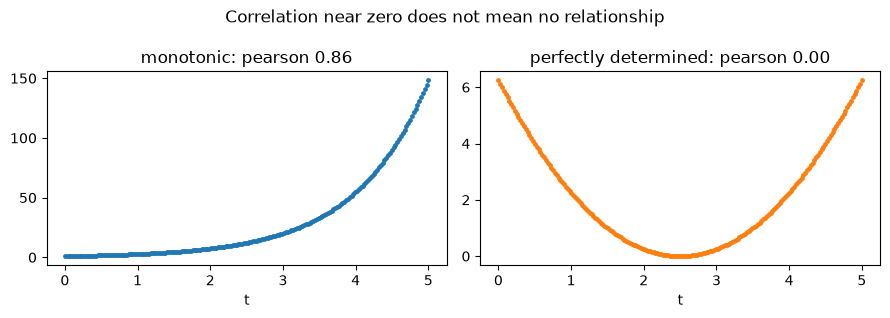

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].scatter(t, monotonic, s=6)
axes[0].set_title(f"monotonic: pearson {pearsonr(t, monotonic)[0]:.2f}")
axes[1].scatter(t, curved, s=6, color="tab:orange")
axes[1].set_title(f"perfectly determined: pearson {pearsonr(t, curved)[0]:.2f}")
for ax in axes:
    ax.set_xlabel("t")
fig.suptitle("Correlation near zero does not mean no relationship")
fig.tight_layout()
plt.show()

**Correlation is not causation, and in ML it does not need to be.** A predictive model exploits association
regardless of its cause, and that is legitimate — until someone acts on it. "Customers who contact support
churn more" supports *predicting* churn; it does not support *closing the support line*. 24.4 returns to
this distinction, which is where interpretability and causal claims part company.

#### 2.8.3 Sampling, the central limit theorem and hypothesis tests

Any dataset is a **sample** from a larger population, so every statistic computed from it is itself a
random quantity that would come out differently on a different sample. The **central limit theorem** says
that the sample *mean* is approximately normally distributed regardless of the population's shape, provided
the sample is large enough.

In [34]:
population = rng.exponential(scale=2.0, size=200_000)   # heavily right-skewed, nothing like a bell

sample_means = np.array([rng.choice(population, size=50).mean() for _ in range(2000)])

print(f"population: mean {population.mean():.3f}  skew heavy, min {population.min():.4f}")
print(f"sample means (n=50): mean {sample_means.mean():.3f}  std {sample_means.std():.3f}")
print(f"predicted std (sigma/sqrt(n)): {population.std() / np.sqrt(50):.3f}")   # matches

population: mean 1.991  skew heavy, min 0.0000
sample means (n=50): mean 1.985  std 0.273
predicted std (sigma/sqrt(n)): 0.282


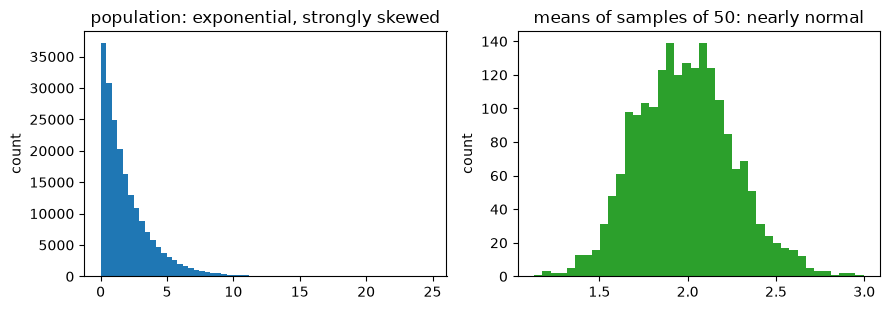

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(population, bins=60, color="tab:blue")
axes[0].set_title("population: exponential, strongly skewed")
axes[1].hist(sample_means, bins=40, color="tab:green")
axes[1].set_title("means of samples of 50: nearly normal")
for ax in axes:
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()

The quantity $\sigma / \sqrt{n}$ is the **standard error** — the typical distance between a sample mean and
the truth. Its $\sqrt{n}$ shrinks slowly, which is a fact with direct consequences: quadrupling a test set
only halves the uncertainty in its score. That is why 8.3 prefers cross-validation to a single large
hold-out, and why comparing two models whose scores differ by less than their standard error is not a
comparison at all.

A **hypothesis test** formalizes that comparison. The **p-value** is the probability of seeing a difference
at least this large *if there were no real difference*. It is not the probability that the models are the
same.

In [36]:
from scipy.stats import ttest_ind

model_a = rng.normal(0.850, 0.02, 30)   # 30 CV fold scores
model_b = rng.normal(0.856, 0.02, 30)   # genuinely better, but only just

stat, p = ttest_ind(model_a, model_b)
print(f"mean A {model_a.mean():.4f}   mean B {model_b.mean():.4f}")
print(f"p-value {p:.3f} -> ", "difference is detectable" if p < 0.05 else "cannot distinguish them")

mean A 0.8512   mean B 0.8591
p-value 0.129 ->  cannot distinguish them


**Common mistake — testing many things and reporting the winner.** Run twenty comparisons at the 5% level
on data with no real differences and, on average, one comes back "significant" by construction. This is
exactly what a hyperparameter search does — it runs hundreds of comparisons and reports the maximum — which
is why the best cross-validation score from a search is a biased estimate and needs a held-out set or
nested CV to correct (23.8).

In [37]:
significant = 0
for _ in range(20):
    a = rng.normal(0, 1, 30)
    b = rng.normal(0, 1, 30)   # SAME distribution - no real difference exists
    if ttest_ind(a, b)[1] < 0.05:
        significant += 1

print(f"'significant' results among 20 tests of nothing: {significant}")   # ~1

'significant' results among 20 tests of nothing: 1


### 2.9 In Practice

#### 2.9.1 Where this shows up: a linear model returning nonsense

The most common way this chapter's material surfaces in real work is a fitted model whose coefficients are
absurd — enormous, wildly signed, and unstable between runs. The maths above diagnoses it in three lines.

The scenario: a colleague's feature table has `total_spend`, and also `total_spend_usd` — the same quantity
after a currency conversion that was later reverted, so the two columns now differ only by floating-point
dust. Nobody noticed, because nothing errors.

In [38]:
from sklearn.linear_model import LinearRegression, Ridge

case_rng = np.random.default_rng(RANDOM_STATE)   # own generator: this case stands alone

n_obs = 200
monthly = case_rng.uniform(20, 100, n_obs)
tenure = case_rng.uniform(1, 72, n_obs)
total_spend = monthly * tenure
total_spend_usd = total_spend + case_rng.normal(0, 1e-6, n_obs)   # the "same" column, off by dust

X_bad = np.column_stack([monthly, tenure, total_spend, total_spend_usd])
y_bad = 0.5 * monthly + 0.2 * tenure + case_rng.normal(0, 1.0, n_obs)

print("rank       :", np.linalg.matrix_rank(X_bad))            # 4 - technically FULL rank
print("cond(X)    :", f"{np.linalg.cond(X_bad):.3e}")           # 5.319e+09
print("cond(X^T X):", f"{np.linalg.cond(X_bad.T @ X_bad):.3e}")   # 7.744e+15 - squared, and now hopeless

rank       : 4
cond(X)    : 5.319e+09
cond(X^T X): 7.744e+15


Two things to read here. First, **rank says the matrix is fine and the condition number says it is not**.
`matrix_rank` answers "are any columns *exactly* dependent?"; the condition number answers "are any columns
*nearly* dependent?" — and on real data only the second question matters. A rank check alone would have
cleared this design matrix.

Second, forming $X^\top X$ **squares** the condition number, from $10^{9}$ to $10^{15}$. That is the
stability row of 2.5.2's table made concrete, and it is why the textbook normal equation is the worst way
to solve this in practice.

Now solve it three ways — the textbook formula, NumPy's least-squares routine, and scikit-learn.

In [39]:
# 1. The textbook normal equation, exactly as written in 11.3, with an explicit inverse.
normal_eq = np.linalg.inv(X_bad.T @ X_bad) @ X_bad.T @ y_bad

# 2. NumPy's least-squares solver (SVD-based, no inverse formed).
lstsq_sol = np.linalg.lstsq(X_bad, y_bad, rcond=None)[0]

# 3. scikit-learn (also SVD-based, but with its own small-singular-value cutoff).
sklearn_sol = LinearRegression(fit_intercept=False).fit(X_bad, y_bad).coef_

print("true effects  : [0.5    0.2    0.0    0.0   ]")
print("inv(X^T X)    :", normal_eq)
print("np.lstsq      :", lstsq_sol)
print("sklearn       :", sklearn_sol)

true effects  : [0.5    0.2    0.0    0.0   ]
inv(X^T X)    : [  0.643   0.278  19.056 -19.06 ]
np.lstsq      : [     0.499      0.2   -69724.246  69724.246]
sklearn       : [0.499 0.199 0.    0.   ]


**Three solvers, three completely different answers to the same problem.** This is the moment the
mathematics stops being decoration:

| Solver | `monthly` | `tenure` | The two spend columns |
|---|---|---|---|
| `inv(XᵀX)` | 0.643 — **wrong** | 0.278 — **wrong** | ±19, cancelling |
| `np.linalg.lstsq` | 0.499 ✓ | 0.200 ✓ | ±69724, cancelling |
| `LinearRegression` | 0.499 ✓ | 0.199 ✓ | 0.0, 0.0 |

The explicit inverse is the only one that corrupts the *good* coefficients too — 2.4's "if you are writing
`inv`, you want `solve`" is not a style preference, it is the difference between 0.643 and 0.499 on a
coefficient someone is going to quote in a meeting.

But look at `lstsq`: it recovers `monthly` and `tenure` perfectly and still reports a spend coefficient of
about **±70,000**. It is not broken. The problem genuinely has no unique answer, and `lstsq` returns the
minimum-norm one among infinitely many; scikit-learn returns a different one because it discards singular
values below a cutoff. Both are defensible; neither is *the* answer, because there isn't one.

**Proving the problem is non-identifiable.** If two coefficient vectors that differ enormously make the same predictions, the data cannot distinguish
between them. Add 1000 to one spend coefficient and subtract 1000 from the other:

In [40]:
alt = lstsq_sol.copy()
alt[2] += 1000.0
alt[3] -= 1000.0     # the two columns are near-identical, so this nearly cancels

pred_original = X_bad @ lstsq_sol
pred_alt = X_bad @ alt

print("largest prediction difference:", f"{np.abs(pred_original - pred_alt).max():.6f}")
print(f"RMSE original: {np.sqrt(((y_bad - pred_original)**2).mean()):.10f}")
print(f"RMSE altered : {np.sqrt(((y_bad - pred_alt)**2).mean()):.10f}")

largest prediction difference: 0.002965
RMSE original: 1.0328534299
RMSE altered : 1.0328539111


The coefficients differ by 2000 and the predictions differ by three thousandths; the two models are
indistinguishable to ten decimal places of RMSE. **No amount of data, no better solver and no evaluation
metric can tell these two models apart**, because the information needed to separate the two columns is not
in the data. The question "what is the effect of `total_spend`?" has no answer here — not an
uncertain answer, no answer.

**The fixes.**

In [41]:
# Fix 1: drop the duplicate (2.4.1 - it carries no independent information).
print("duplicate dropped :", LinearRegression(fit_intercept=False).fit(X_bad[:, :3], y_bad).coef_)

# Fix 2: ridge on STANDARDIZED features (2.4.2; 12.8 on why the scaling is mandatory).
X_std = (X_bad - X_bad.mean(axis=0)) / X_bad.std(axis=0)
print("ridge (standardized):", Ridge(alpha=1.0).fit(X_std, y_bad).coef_)

duplicate dropped : [0.499 0.199 0.   ]
ridge (standardized): [11.132  3.916  0.114  0.114]


Dropping the duplicate restores a unique solution and the true effects come straight back. Ridge takes a
different route: the $\lambda I$ term makes the problem identifiable again (2.4.2) and splits the shared
effect **evenly** between the two duplicate columns — `0.114` each — which is a principled, reproducible
choice rather than an arbitrary one. Note that ridge's coefficients are on standardized features, so they
are in standard-deviation units and are not comparable to the raw `0.5` and `0.2`.

Dropping the column is the right fix here because the duplication is a data bug. Ridge is the right fix
when features are genuinely correlated and none of them can be discarded.

**The finding, in one sentence for a colleague:** *`total_spend_usd` duplicates `total_spend`, making the
design matrix ill-conditioned ($\kappa \approx 5\times10^9$); the spend coefficients are non-identifiable —
values 2000 apart fit the data identically — so no conclusion may be drawn from them, and the numbers
differ depending on which solver was used.* Every claim in that sentence was supported by three lines of
NumPy. 11.7 turns the check into a routine one using the variance inflation factor.

#### 2.9.2 When you need the maths — and when the library is enough

| Situation | Do you need this chapter? |
|---|---|
| Fitting a model and reading a score | **No.** The library handles it |
| Choosing between ridge and lasso | **Yes** — it is an $L_2$-vs-$L_1$ choice (2.3) and nothing else |
| A model returns absurd or unstable coefficients | **Yes** — rank and condition number (2.4) |
| Deciding how many PCA components to keep | **Yes** — explained variance is eigenvalue share (2.5.1) |
| Implementing a custom loss or a gradient | **Yes** — and verify it numerically (2.6.2) |
| A probability output looks impossible | **Yes** — usually base rates (2.7.3) |
| Comparing two models' scores | **Yes** — standard error and multiple comparisons (2.8.3) |
| Explaining a correlation to a stakeholder | **Yes** — Pearson's blind spot and causation (2.8.2) |
| Choosing a distance metric for k-NN | **Yes** — it is a norm choice (2.3) |
| Picking `n_estimators` for a random forest | **No.** Search it (23.5) |

The pattern: the maths is not needed to *run* things. It is needed to explain a result that looks wrong,
and to know whether a result that looks right actually is.

#### 2.9.3 What goes wrong in production

Numerical failures are quiet. None of these raises an exception:

| Failure | What happens | Where it bites |
|---|---|---|
| **Ill-conditioning** | Coefficients are numerical noise; predictions may still look fine | Any linear model on correlated features (11.7) |
| **Underflow in probability products** | Multiplying many small probabilities reaches exactly 0.0 | Naive Bayes on long documents — hence log space (15.6) |
| **float32 vs float64** | A pipeline that silently downcasts loses precision; results drift from the notebook | Serving code, ONNX/TensorRT export |
| **Catastrophic cancellation** | Subtracting two nearly equal large numbers destroys precision | Naive variance formulas, incremental statistics |
| **Non-associative float addition** | Parallel or reordered summation changes the last digits | `n_jobs > 1`, GPU inference, differing thread counts |
| **Eigenvector sign flips** | Plots and loadings invert between runs (2.5.3) | Hand-rolled PCA, saved component matrices |

The underflow row is the one that most often reaches production undetected, so it is worth seeing happen.

In [42]:
probabilities = np.full(800, 0.1)   # 800 independent features, each with a small likelihood

naive = np.prod(probabilities)
log_space = np.sum(np.log(probabilities))

print("product in normal space:", naive)              # 0.0 - underflowed to exactly zero
print("sum of logs            :", log_space.round(2))  # -1842.07 - perfectly representable
print("recovered exponent     :", f"e^{log_space:.1f}")

product in normal space: 0.0
sum of logs            : -1842.07
recovered exponent     : e^-1842.1


In normal space the answer is exactly `0.0`, and comparing two classes both scoring `0.0` is a coin flip.
In log space the same quantity is an ordinary number and the comparison is exact. Every serious
implementation of Naive Bayes works this way — `sklearn`'s exposes it as `predict_log_proba` — and 15.6
covers it as a first-class technique rather than an optimization.

The general rule this chapter leaves you with: **when a numerical result is surprising, check the
conditioning and the scale before questioning the model.** Most inexplicable machine learning results are
explicable arithmetic.

In [43]:
# --- 2. Mathematical Foundations — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.